# Quiz 3 - Programming Excercises

## Logistic Regression

In this exercise, you will implement a Logistic Regression model and explore different stepsize policies for the Stochastic Gradient Descent algorithm using the [Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).

The code below prepares the data required for this exercise.

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer

# load the data
X, y = load_breast_cancer(return_X_y=True)

print(f"Shape of input data: {X.shape}")
print(f"Shape of output data: {y.shape}")

mdata, ndim = X.shape 

# convert the output space from {0,1} into {-1,+1}
y = 2*y - 1

# normalization
X /= np.outer(np.ones(mdata), np.max(np.abs(X),0))

Shape of input data: (569, 30)
Shape of output data: (569,)


**Task 1**: Complete the `logreg_sgd_cls` class provided below to implement a Logistic Regression class.

<div class="alert alert-info">
<b>Note:</b> Be aware that the Logistic Regression algorithm presented in Lecture 5 may differ from the one implemented in Sklearn. Please use the version presented in the Lecture.
</div>

In [15]:
class logreg_sgd_cls:
    """ 
    Logistic Regression Classifier
     
    """
    def __init__(self):
        self.nitermax = 100     # maximum iteration
        self.eta = 0.1          # initial step size
        self.w = None           # weights to learn

    ## ------------------------------------------
    def fit(self, X, y, eta, nitermax, diminish=0):
        """ Train the logistic regression model
            with stochastic gradient descent algorithm

        Input:  X         2D array where each row represents an input example
                y         1D array(vector) of +1,-1 labels
                eta       initial step size
                nitermax  maximum number of iterations
                diminish  =0 constant step size, =1 diminishing step size
        """
        mtrain, ndim = X.shape

        # initialize the weights
        w = np.zeros(ndim)

        # iterations on the full data
        for t in range(nitermax):

            # select the stepsize
            if diminish == 1:       # diminishing stepsize policy
                etat = eta/(t+1)    # t+1 to avoid division by zero
            else:                   # constant stepsize policy
                etat = eta

            # perform one step of stochastic gradient descent on each training example
            for i in range(mtrain):
                xi = X[i]
                yi = y[i]

                # Compute the margin
                margin = yi * np.dot(w, xi)

                # Compute the gradient
                grad = -yi * xi / (1 + np.exp(margin))

                # Update the weight
                w = w - etat * grad
                

        # save the final weights to the model
        self.w  = w

        return(w)

    ## ------------------------------------------
    def predict(self, X):
        """ Predict the labels

        Input:
            X   2D array where each row represents an input example

        Output:
            y   1D array of predicted labels
        """

        z = X @ self.w


        y = np.where(z >= 0, 1, -1)
        
        return(y)

**Task 2**: Complete the helper function below for running n-Fold cross validation.

In [18]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

def learning_cycle(X, y, niteration, eta, stepsize_type, nfold):
    """
    Helper function for running n-Fold cross validation
    Input:  X              2d array of inputs
            y              1d array of outputs
            niteration     number of iteration for gradient descent
            eta            initial stepsize
            stepsize_type  =0 constant, =1 diminishing
            nfold          number of folds for cross-validation
    Output: xf1score       1D array of size [nfold] containing the f1 scores for each fold        
    """

    # split the data into n folds
    cselection = KFold(n_splits=nfold, random_state=None, shuffle=False)

    # array to collect the results for each fold
    xf1score = np.zeros(nfold)
    
    # create an instance of the logistic regression model
    clogreg = logreg_sgd_cls()


    # perform n-fold cross-validation
    for ifold, (index_train, index_test) in enumerate(cselection.split(X)):
        # TODO: train the model, and evaluate using F1 score for each fold
        
        X_train = X[index_train]
        X_test = X[index_test]
        y_train = y[index_train]
        y_test = y[index_test]

        clogreg.fit(X=X_train, y=y_train, eta=eta, nitermax=niteration, diminish=stepsize_type)

        y_pred = clogreg.predict(X=X_test)

        xf1score[ifold] = f1_score(y_test, y_pred, average="macro")       

    return(xf1score)

**Task 3**: Execute n-fold cross-validation and answer question 4 according to the results.

In [29]:
# Learning hyperparameters
# create the list of initial step sizes (learning rates)
neta = 40   # number of different step size
eta0 = 0.2
# list of initial step sizes
leta = [ eta0*(i+1) for i in range(neta)]

# number of iterations in gradient descent
iteration = 50

# number of folds 
nfold = 5

# fix the random seed
rng = np.random.default_rng(12345)

# number of different stepsize policies
nstepsize_type = 2

# array to collect the test scores for the two stepsize policies
xmean_test_results = np.zeros((neta, nstepsize_type))


# Run cross-validation
# enumerate stepsize policies
for istepsize in [0, 1]:    # 0 - constant, 1 - diminishing

    xf1score_eta = np.zeros(neta)

    # enumerate the (initial) stepsizes
    for ieta in range(neta):
        eta = leta[ieta]

        # n-fold cross-validation
        xf1score = learning_cycle(X, y, iteration, eta, istepsize, nfold)
        # compute the mean of the test accuracies
        xf1score_eta[ieta] = np.mean(xf1score)

    xmean_test_results[:, istepsize] = xf1score_eta

# values of the curves in the graph  
for i in range(nstepsize_type):
    for j in range(neta):
        if i == 0:
            print('%6.4f'%leta[j],'%6.4f'%xmean_test_results[j, i], i)

0.2000 0.9419 0
0.4000 0.9483 0
0.6000 0.9502 0
0.8000 0.9467 0
1.0000 0.9415 0
1.2000 0.9415 0
1.4000 0.9397 0
1.6000 0.9377 0
1.8000 0.9377 0
2.0000 0.9377 0
2.2000 0.9377 0
2.4000 0.9338 0
2.6000 0.9338 0
2.8000 0.9373 0
3.0000 0.9354 0
3.2000 0.9463 0
3.4000 0.9403 0
3.6000 0.9435 0
3.8000 0.9504 0
4.0000 0.9528 0
4.2000 0.9272 0
4.4000 0.9445 0
4.6000 0.9478 0
4.8000 0.9506 0
5.0000 0.9459 0
5.2000 0.9325 0
5.4000 0.9234 0
5.6000 0.9200 0
5.8000 0.9298 0
6.0000 0.9215 0
6.2000 0.9162 0
6.4000 0.9317 0
6.6000 0.9254 0
6.8000 0.9477 0
7.0000 0.9189 0
7.2000 0.9288 0
7.4000 0.9185 0
7.6000 0.9224 0
7.8000 0.9207 0
8.0000 0.9106 0


In [24]:
policies = ['constant', 'diminishing']

for i in range(nstepsize_type):
    best_idx = np.argmax(xmean_test_results[:, i]) # row with highest 
    print(f"{policies[i]:12s}  best eta = {leta[best_idx]:.1f}   mean F1 = {xmean_test_results[best_idx, i]:.4f}")

constant      best eta = 4.0   mean F1 = 0.9528
diminishing   best eta = 5.4   mean F1 = 0.9626


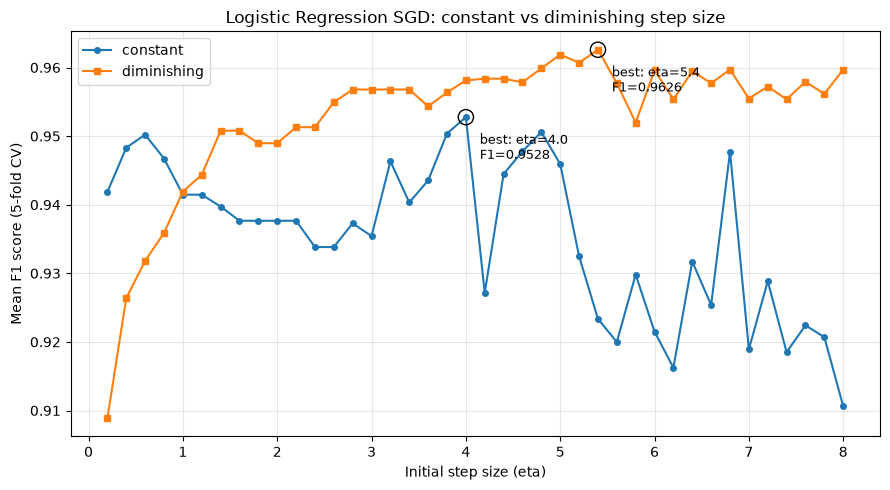

In [30]:
import matplotlib.pyplot as plt

policies = ["constant", "diminishing"]
markers = ["o", "s"]

fig, ax = plt.subplots(figsize=(9, 5))

for i in range(nstepsize_type):
    scores = xmean_test_results[:, i]
    ax.plot(leta, scores, marker=markers[i], markersize=4, label=policies[i])

    # highlight the best eta for this policy
    best = np.argmax(scores)
    ax.scatter(leta[best], scores[best], s=120, facecolors="none", edgecolors="black", zorder=3)
    ax.annotate(f"best: eta={leta[best]:.1f}\nF1={scores[best]:.4f}",
                (leta[best], scores[best]),
                textcoords="offset points", xytext=(10, -30), fontsize=9)

ax.set_xlabel("Initial step size (eta)")
ax.set_ylabel("Mean F1 score (5-fold CV)")
ax.set_title("Logistic Regression SGD: constant vs diminishing step size")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
